Time Series Analysis on :
1.Monthly Cola Production in Australia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Collecting data 
df = pd.read_csv('monthly-cola-production-in-austr.csv')
print(df.head())
print(df.info())

     Month  cola
0  1956-01  93.2
1  1956-02  96.0
2  1956-03  95.2
3  1956-04  77.1
4  1956-05  70.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   476 non-null    object 
 1   cola    476 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.6+ KB
None


In [3]:
#Converting to required time series format
df['yearMonth'] = pd.to_datetime(df['Month'])
print(df.head())
print(df.info())

     Month  cola  yearMonth
0  1956-01  93.2 1956-01-01
1  1956-02  96.0 1956-02-01
2  1956-03  95.2 1956-03-01
3  1956-04  77.1 1956-04-01
4  1956-05  70.9 1956-05-01
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Month      476 non-null    object        
 1   cola       476 non-null    float64       
 2   yearMonth  476 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 11.3+ KB
None


In [4]:
#Setting index
df.set_index('yearMonth',inplace = True)
print(df.head())
print(df.tail())

              Month  cola
yearMonth                
1956-01-01  1956-01  93.2
1956-02-01  1956-02  96.0
1956-03-01  1956-03  95.2
1956-04-01  1956-04  77.1
1956-05-01  1956-05  70.9
              Month   cola
yearMonth                 
1995-04-01  1995-04  127.0
1995-05-01  1995-05  151.0
1995-06-01  1995-06  130.0
1995-07-01  1995-07  119.0
1995-08-01  1995-08  153.0


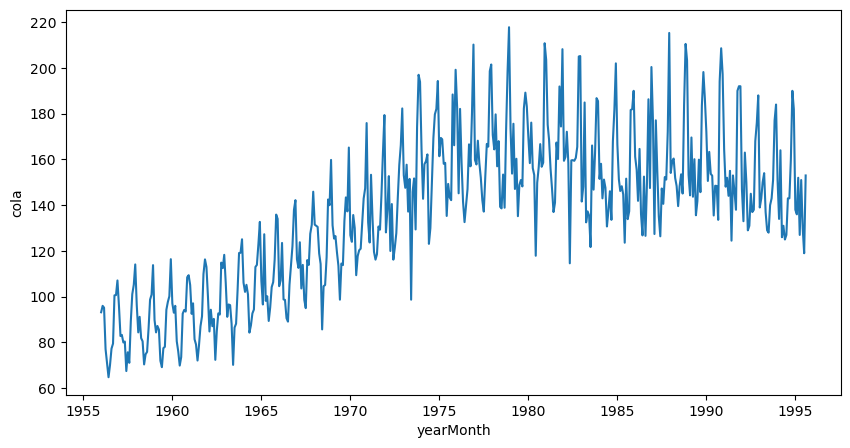

In [5]:
#Visualize
plt.figure(figsize=(10,5))
sns.lineplot(data = df, x=df.index, y=df.cola)
plt.show()

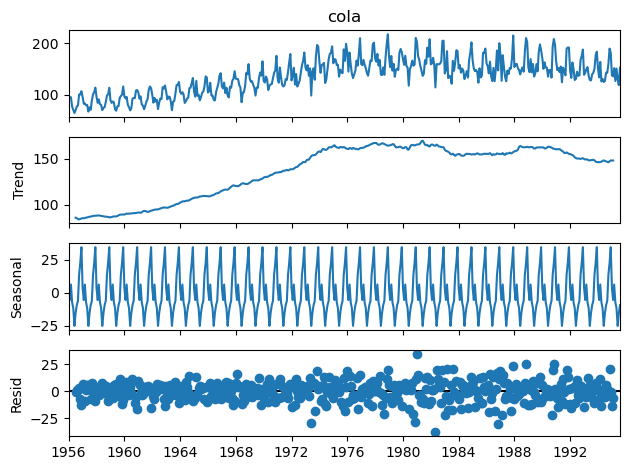

In [6]:
#Check further for seasonality and trend by doing decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df.cola, period =12)
fig =decomposition.plot()
plt.show()

In [7]:
#rolling mean and std for 12 months
df['rollMean'] = df.cola.rolling(window =12).mean()
df['rollStd'] = df.cola.rolling(window = 12).std()

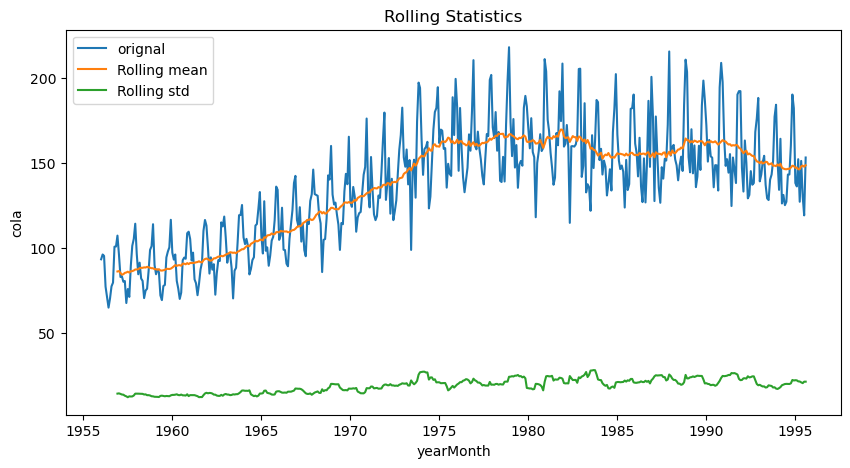

In [8]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index, y = df.cola, label="orignal")
sns.lineplot(data=df,x=df.index, y = df.rollMean, label="Rolling mean")
sns.lineplot(data=df,x=df.index, y = df.rollStd, label="Rolling std")
plt.title("Rolling Statistics")
plt.show()

ADF p-value: 0.1776
The time series is not stationary (fail to reject H0).


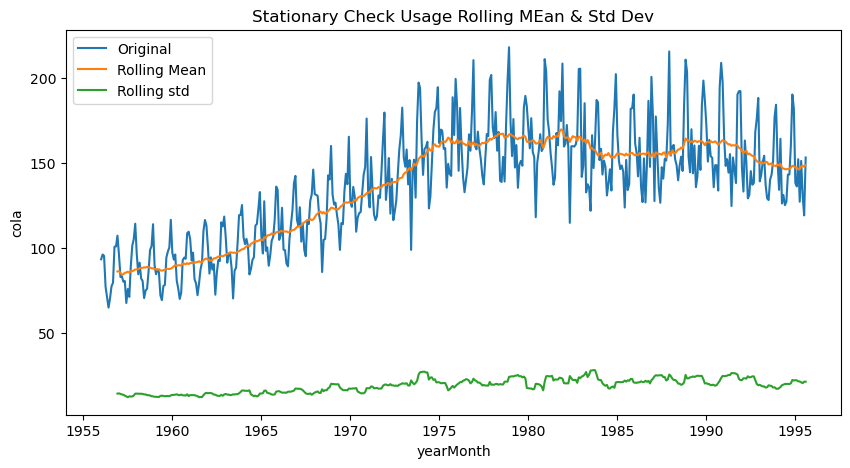

In [9]:
def test_stationary(dataFrame, var):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()

    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]

    print(f"ADF p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("The time series is stationary(reject H0).")
    else:
        print("The time series is not stationary (fail to reject H0).")

    #plot
    plt.figure(figsize=(10,5))
    sns.lineplot(data=dataFrame, x=dataFrame.index, y=var, label='Original')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollMean',label='Rolling Mean')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollStd', label='Rolling std')
    plt.title("Stationary Check Usage Rolling MEan & Std Dev")
    plt.legend()
    plt.show()

#calling the function to test functionality
test_stationary(df,'cola')

             cola  shift  shiftDiff
yearMonth                          
1956-01-01   93.2    NaN        NaN
1956-02-01   96.0   93.2        2.8
1956-03-01   95.2   96.0       -0.8
1956-04-01   77.1   95.2      -18.1
1956-05-01   70.9   77.1       -6.2
1956-06-01   64.8   70.9       -6.1
1956-07-01   70.1   64.8        5.3
1956-08-01   77.3   70.1        7.2
1956-09-01   79.5   77.3        2.2
1956-10-01  100.6   79.5       21.1
1956-11-01  100.7  100.6        0.1
1956-12-01  107.1  100.7        6.4
1957-01-01   95.9  107.1      -11.2
1957-02-01   82.8   95.9      -13.1
1957-03-01   83.3   82.8        0.5
1957-04-01   80.0   83.3       -3.3
1957-05-01   80.4   80.0        0.4
1957-06-01   67.5   80.4      -12.9
1957-07-01   75.7   67.5        8.2
1957-08-01   71.1   75.7       -4.6
ADF p-value: 0.0000
The time series is stationary(reject H0).


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_20048\1681547611.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_20048\1681547611.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()


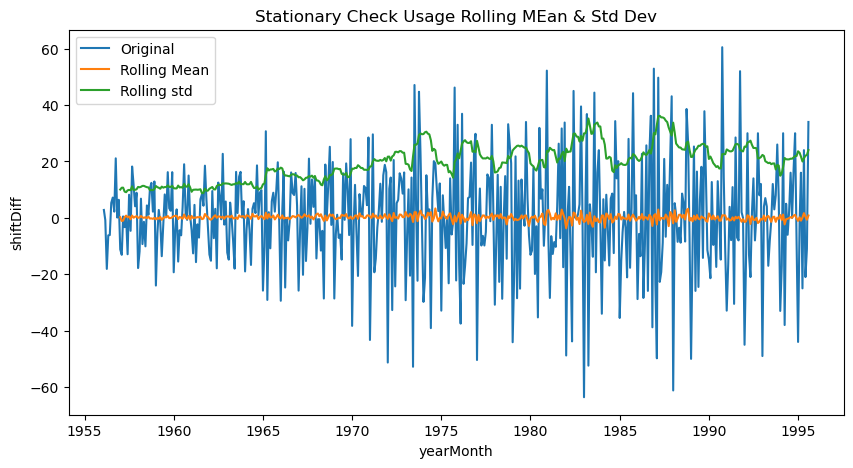

In [10]:
cola_df = df[['cola']].copy()

cola_df['shift'] = cola_df.cola.shift(1)
cola_df['shiftDiff'] = cola_df['cola'] - cola_df['shift']
print(cola_df.head(20))
#Test stationarity
test_stationary(cola_df.dropna(),'shiftDiff')

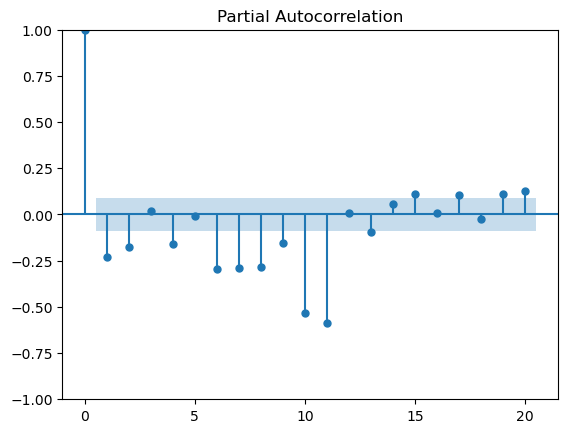

In [11]:
#ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_pacf(cola_df['shiftDiff'].dropna(),lags=20)
plt.show()

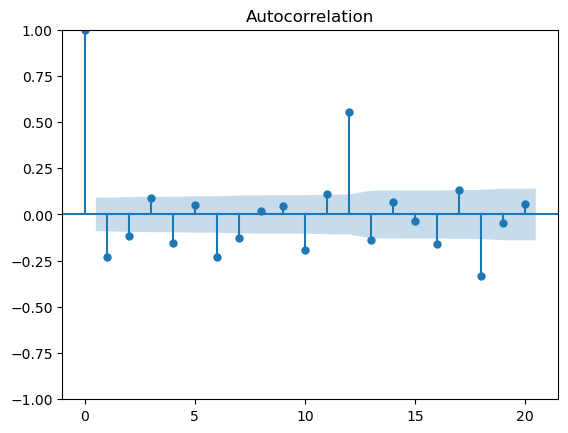

In [12]:
plot_acf(cola_df['shiftDiff'].dropna(), lags =20)
plt.show()

In [13]:
train = cola_df[:round(len(cola_df)*70/100)] 
print(train.head()) 

test = cola_df[round(len(cola_df)*71/100):] 
print(test.head())

model = ARIMA(train['cola'], order =(1,1,1)) 
model_fit =model.fit()
prediction = model_fit.predict(start = test.index[0], end = test.index[-1])
cola_df['arimaPred'] = prediction
print(cola_df.tail())

            cola  shift  shiftDiff
yearMonth                         
1956-01-01  93.2    NaN        NaN
1956-02-01  96.0   93.2        2.8
1956-03-01  95.2   96.0       -0.8
1956-04-01  77.1   95.2      -18.1
1956-05-01  70.9   77.1       -6.2
             cola  shift  shiftDiff
yearMonth                          
1984-03-01  143.0  158.1      -15.1
1984-04-01  151.2  143.0        8.2
1984-05-01  147.6  151.2       -3.6
1984-06-01  130.7  147.6      -16.9
1984-07-01  137.5  130.7        6.8
             cola  shift  shiftDiff  arimaPred
yearMonth                                     
1995-04-01  127.0  152.0      -25.0  157.58907
1995-05-01  151.0  127.0       24.0  157.58907
1995-06-01  130.0  151.0      -21.0  157.58907
1995-07-01  119.0  130.0      -11.0  157.58907
1995-08-01  153.0  119.0       34.0  157.58907


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['cola'],order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()
prediction = model_fit.predict(start=test.index[0], end =test.index[-1])
cola_df['sarimaxPred'] = prediction
print(cola_df.tail())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


             cola  shift  shiftDiff  arimaPred  sarimaxPred
yearMonth                                                  
1995-04-01  127.0  152.0      -25.0  157.58907   155.686537
1995-05-01  151.0  127.0       24.0  157.58907   150.446282
1995-06-01  130.0  151.0      -21.0  157.58907   141.082517
1995-07-01  119.0  130.0      -11.0  157.58907   146.442692
1995-08-01  153.0  119.0       34.0  157.58907   161.175527


            cola  shift  shiftDiff  arimaPred  sarimaxPred
yearMonth                                                 
1956-01-01  93.2    NaN        NaN        NaN          NaN
1956-02-01  96.0   93.2        2.8        NaN          NaN
1956-03-01  95.2   96.0       -0.8        NaN          NaN
1956-04-01  77.1   95.2      -18.1        NaN          NaN
1956-05-01  70.9   77.1       -6.2        NaN          NaN


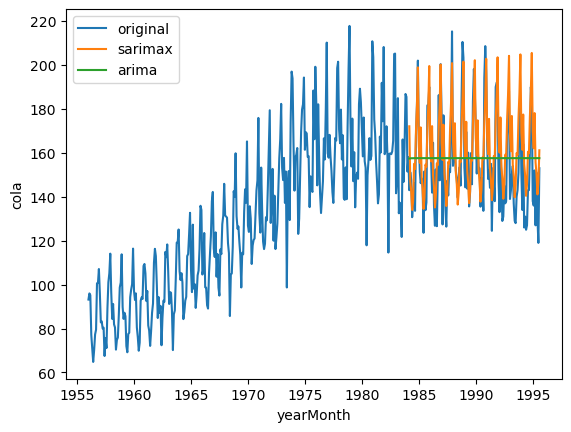

In [15]:
cola_df.dropna()
print(cola_df.head())
sns.lineplot(data=cola_df, x=cola_df.index, y ="cola", label = "original")
sns.lineplot(data=cola_df, x=cola_df.index, y='sarimaxPred',label ="sarimax")
sns.lineplot(data=cola_df, x=cola_df.index, y='arimaPred', label = "arima")
plt.show()

In [16]:
#Future Prediction
futureDate = pd.DataFrame(pd.date_range(start="1996-01-01", end="1997-12-01", freq="MS"),columns=["Dates"])
futureDate.set_index("Dates", inplace=True)
print(futureDate.head())

Empty DataFrame
Columns: []
Index: [1996-01-01 00:00:00, 1996-02-01 00:00:00, 1996-03-01 00:00:00, 1996-04-01 00:00:00, 1996-05-01 00:00:00]


1996-01-01    170.498106
1996-02-01    162.733627
1996-03-01    178.775202
1996-04-01    156.348218
1996-05-01    151.107963
1996-06-01    141.744198
1996-07-01    147.104373
1996-08-01    161.837208
1996-09-01    161.013545
1996-10-01    177.782131
1996-11-01    189.367169
1996-12-01    206.813304
1997-01-01    171.159786
1997-02-01    163.395308
1997-03-01    179.436882
1997-04-01    157.009898
1997-05-01    151.769643
1997-06-01    142.405878
1997-07-01    147.766053
1997-08-01    162.498888
1997-09-01    161.675225
1997-10-01    178.443811
1997-11-01    190.028850
1997-12-01    207.474985
Freq: MS, Name: predicted_mean, dtype: float64


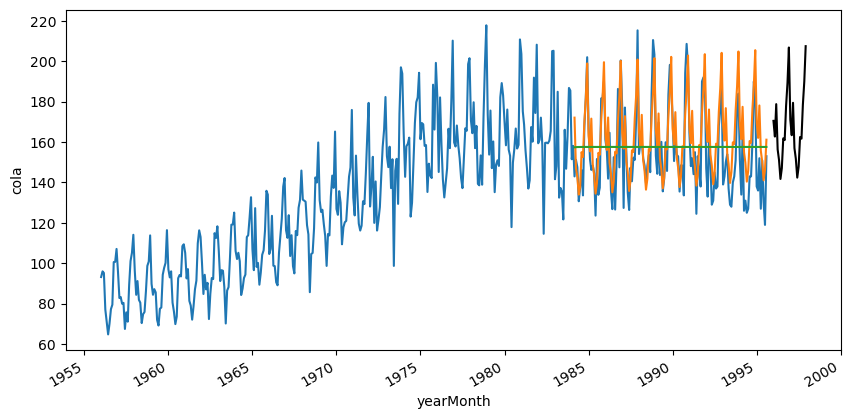

In [17]:
print(model_fit.predict(start=futureDate.index[0], end=futureDate.index[-1]))

#plot
cola_df.dropna()
plt.figure(figsize=(10,5))
sns.lineplot(data=cola_df, x=cola_df.index, y="cola")
sns.lineplot(data=cola_df, x=cola_df.index, y="sarimaxPred")
sns.lineplot(data=cola_df, x=cola_df.index, y="arimaPred")
model_fit.predict(start=futureDate.index[0], end=futureDate.index[-1]).plot(color="black")
plt.show()

In [18]:
#Model evaluation
cola_df = cola_df.dropna()
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

#arima evaluation
mae = mean_absolute_error(cola_df["cola"],cola_df["arimaPred"])
rmse = root_mean_squared_error(cola_df["cola"],cola_df["arimaPred"])
r2 = r2_score(cola_df["cola"], cola_df["arimaPred"])
print(f"ARIMA MAE: {mae}, RMSE : {rmse}, R^2: {r2}")

ARIMA MAE: 18.068251783396853, RMSE : 21.767701839184827, R^2: -0.02002508696446781


In [19]:
cola_df = cola_df.dropna()
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

#arima evaluation
mae = mean_absolute_error(cola_df["cola"],cola_df["sarimaxPred"])
rmse = root_mean_squared_error(cola_df["cola"],cola_df["sarimaxPred"])
r2 = r2_score(cola_df["cola"], cola_df["sarimaxPred"])
print(f"SARIMAX MAE: {mae}, RMSE : {rmse}, R^2: {r2}")

SARIMAX MAE: 12.367977472392965, RMSE : 15.17110218853514, R^2: 0.5045270377267537
